<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [3]:
df=pd.DataFrame()

In [5]:
df['X1']=[1,2,3,4,5,6,6,7,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]

In [6]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

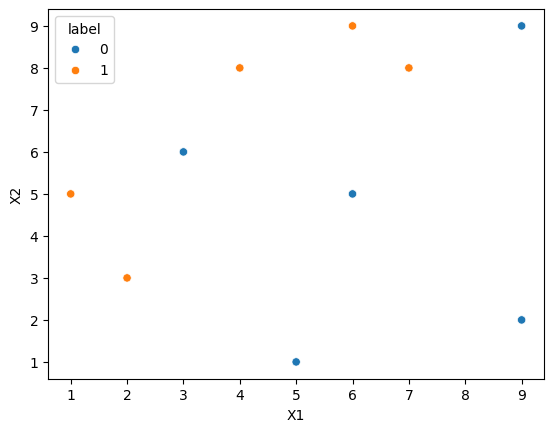

In [7]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [16]:
# step1 define weight for each row
df['weight']=1/df.shape[0]

In [10]:
df

,X1,X2,label,weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [11]:
from sklearn.tree import DecisionTreeClassifier


In [12]:
dt1=DecisionTreeClassifier(max_depth=1)


In [13]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [14]:
print(X)
print(y)

[[1 5]
 [2 3]
 [3 6]
 [4 8]
 [5 1]
 [6 9]
 [6 5]
 [7 8]
 [9 9]
 [9 2]]
[1 1 0 1 0 1 0 1 0 0]


In [15]:
# step2 train the forst decision tree
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

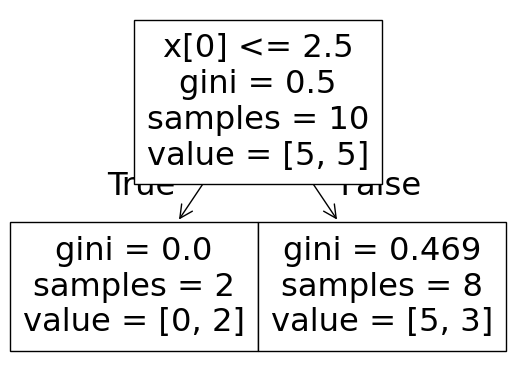

In [17]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

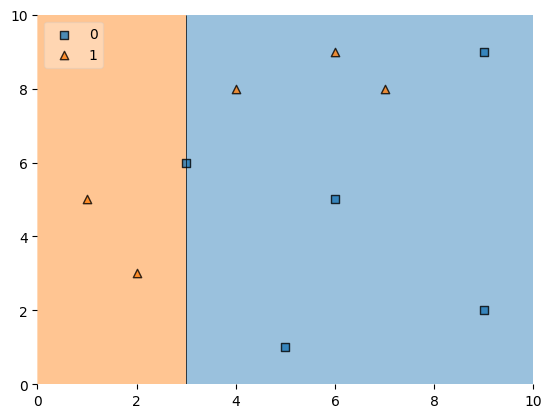

In [18]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [19]:
df['y_pred']=dt1.predict(X)

In [20]:
df

,X1,X2,label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [21]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

In [23]:
# step3 calculate model weight
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [26]:
# update weight
def update_row_weight(row,alpha=0.42364893019360184):
  if row['label']==row['y_pred']:
    return row['weight']*np.exp(-alpha)
  else:
    return row['weight']*np.exp(alpha)

In [27]:
df["updted_weights"]=df.apply(update_row_weight,axis=1)

In [28]:
df

,X1,X2,label,weight,y_pred,updted_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,0,0.065465
3,4,8,1,0.1,0,0.152753
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,0,0.152753
6,6,5,0,0.1,0,0.065465
7,7,8,1,0.1,0,0.152753
8,9,9,0,0.1,0,0.065465
9,9,2,0,0.1,0,0.065465


In [29]:
df['noramlized_weight']=df['updted_weights']/df['updted_weights'].sum()

In [30]:
df

,X1,X2,label,weight,y_pred,updted_weights,noramlized_weight
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,0,0.065465,0.071429
3,4,8,1,0.1,0,0.152753,0.166667
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,0,0.152753,0.166667
6,6,5,0,0.1,0,0.065465,0.071429
7,7,8,1,0.1,0,0.152753,0.166667
8,9,9,0,0.1,0,0.065465,0.071429
9,9,2,0,0.1,0,0.065465,0.071429


In [31]:
df['cusum_upper']=np.cumsum(df['noramlized_weight'])
df['cusum_lower']=1-np.cumsum(df['noramlized_weight'])

In [32]:
df

,X1,X2,label,weight,y_pred,updted_weights,noramlized_weight,cusum_upper,cusum_lower
0,1,5,1,0.1,1,0.065465,0.071429,0.071429,9.285714e-01
1,2,3,1,0.1,1,0.065465,0.071429,0.142857,8.571429e-01
2,3,6,0,0.1,0,0.065465,0.071429,0.214286,7.857143e-01
3,4,8,1,0.1,0,0.152753,0.166667,0.380952,6.190476e-01
4,5,1,0,0.1,0,0.065465,0.071429,0.452381,5.476190e-01
5,6,9,1,0.1,0,0.152753,0.166667,0.619048,3.809524e-01
6,6,5,0,0.1,0,0.065465,0.071429,0.690476,3.095238e-01
7,7,8,1,0.1,0,0.152753,0.166667,0.857143,1.428571e-01
8,9,9,0,0.1,0,0.065465,0.071429,0.928571,7.142857e-02
9,9,2,0,0.1,0,0.065465,0.071429,1.000000,2.220446e-16


In [34]:
def create_new_data_set(df):
  indices=[]


  for i in range(df.shape[0]):
    a=np.random.random()
    for index,row in df.iterrows():
      if row['cusum_upper'] > a  and a > row['cusum_lower']:
        indices.append(index)
  return indices


In [35]:
index_values=create_new_data_set(df)


In [36]:
index_values

[6,
 7,
 8,
 9,
 9,
 7,
 8,
 9,
 9,
 5,
 6,
 7,
 8,
 9,
 8,
 9,
 6,
 7,
 8,
 9,
 7,
 8,
 9,
 7,
 8,
 9,
 5,
 6,
 7,
 8,
 9]

In [37]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [38]:
second_df

,X1,X2,label,weight
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
5,6,9,1,0.1


In [39]:
dt2=DecisionTreeClassifier(max_depth=1)

In [40]:
X=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [41]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [42]:
second_df['y_pred']=dt2.predict(X)


In [43]:
second_df

,X1,X2,label,weight,y_pred
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,1


In [44]:
alpha2=calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [45]:
# update weight
def update_row_weight(row,alpha=1.0986122886681098):
  if row['label']==row['y_pred']:
    return row['weight']*np.exp(-alpha)
  else:
    return row['weight']*np.exp(alpha)

In [46]:
second_df["updted_weights"]=second_df.apply(update_row_weight,axis=1)

In [47]:
second_df['noramlized_weight']=second_df['updted_weights']/second_df['updted_weights'].sum()

In [48]:
second_df['cusum_upper']=np.cumsum(second_df['noramlized_weight'])
second_df['cusum_lower']=1-np.cumsum(second_df['noramlized_weight'])

In [49]:
second_df

,X1,X2,label,weight,y_pred,updted_weights,noramlized_weight,cusum_upper,cusum_lower
6,6,5,0,0.1,1,0.300000,0.142857,0.142857,8.571429e-01
7,7,8,1,0.1,1,0.033333,0.015873,0.158730,8.412698e-01
8,9,9,0,0.1,0,0.033333,0.015873,0.174603,8.253968e-01
9,9,2,0,0.1,0,0.033333,0.015873,0.190476,8.095238e-01
9,9,2,0,0.1,0,0.033333,0.015873,0.206349,7.936508e-01
7,7,8,1,0.1,1,0.033333,0.015873,0.222222,7.777778e-01
8,9,9,0,0.1,0,0.033333,0.015873,0.238095,7.619048e-01
9,9,2,0,0.1,0,0.033333,0.015873,0.253968,7.460317e-01
9,9,2,0,0.1,0,0.033333,0.015873,0.269841,7.301587e-01
5,6,9,1,0.1,1,0.033333,0.015873,0.285714,7.142857e-01


In [50]:
index_values=create_new_data_set(second_df)

In [51]:
third_df=second_df.iloc[index_values,[0,1,2,3]]

In [52]:
third_df

,X1,X2,label,weight
9,9,2,0,0.1
9,9,2,0,0.1
5,6,9,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1
...,...,...,...,...
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1


In [54]:
dt3=DecisionTreeClassifier(max_depth=1)
X=third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

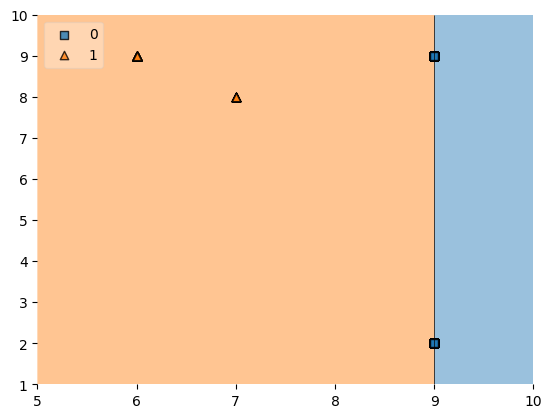

In [55]:
plot_decision_regions(X,y,clf=dt3,legend=2)

In [56]:
third_df['y_pred']=dt3.predict(X)

In [57]:
third_df

,X1,X2,label,weight,y_pred
9,9,2,0,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0
...,...,...,...,...,...
7,7,8,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
9,9,2,0,0.1,0


In [59]:
aplhas3=calculate_model_weight(0.7)
aplhas3

np.float64(-0.4236489301936017)

In [60]:
print(aplhas3,alpha1,alpha2)

-0.4236489301936017 0.42364893019360184 1.0986122886681098


**Prediction**

In [61]:
query=np.array([1,5]).reshape(1,2)

In [62]:
dt1.predict(query)

array([1])

In [63]:
dt2.predict(query)

array([1])

In [64]:
dt3.predict(query)

array([1])

In [66]:
alpha1*dt1.predict(query)+alpha2*dt2.predict(query)+aplhas3*dt3.predict(query)

array([1.09861229])

In [68]:
np.sign(alpha1*dt1.predict(query)+alpha2*dt2.predict(query)+aplhas3*dt3.predict(query))

array([1.])